# Extreme Precipitation Percentile Map

## Purpose
This notebook plots the **extreme precipitation** percentile maps across multiple observational and global storm-resolving model (GSRM) sources, including a second observational product (GsMAP) for cross-checking IMERG. Each percentile map's
zonal-mean panel can optionally shade an interannual IQR band for the two observational products, when their input files carry multi-year data (see `shade_interannual_iqr` in the config cell) -- off by default, since production's current 3-year
IMERG file predates that variable. For the interannual mean/IQR/zonal-with-IQR analysis on its own (11-year IMERG+GsMAP, no GSRM), see the companion notebook `plot_extreme_rain_threshold_map_obs_interannual.ipynb`.

## Input Data
6-hourly extreme precipitation percentile thresholds (variables `pr_p90`, `pr_p95`, in mm/h; some sources also carry the per-calendar-year `pr_annual_p90`/`pr_annual_p95` and their interannual `pr_q25_p*`/`pr_q75_p*`/`pr_iqr_p*` -- only read here when
`shade_interannual_iqr=True` and the specific source's file has them) on a HEALPix zoom 8 grid, one NetCDF file per source. The notebook reads the CFS copy, which is identical file by file to the production copy in
`/pscratch/sd/w/wcmca1/hackathon/extreme_precip/`:
```
/global/cfs/cdirs/wcm_shr/hk25/extreme_precip/<source>_precip_percentiles_6h_hp8_v1.nc
```
These files are generated by:
- **Python script:** `waccem/gsrm_cooccurrencefeature/scripts/calc_extreme_precip_thresholds.py`. Since the 2026-09-20 re-processing the thresholds are computed from Step 1's `tot_pr` (the window-mean precipitation the COF categories are built on;
  IMERG: from its non-IR 6-hourly store) over the wet values only (>= 0.1 mm/h). Since 2026-09-21 the script also computes, for any source with at least 2 qualifying calendar years (`--min_year_coverage_days`, default 300 days), per-year
  percentiles and their interannual IQR (`--no_annual` turns this off).
- **Bash script** (processes all sources): `waccem/gsrm_cooccurrencefeature/scripts/run_all_extreme_precip_thresholds.sh`
- **Pipeline runner** (thresholds and the steps they need, all six sources; it made the files of the 2026-09-20 re-processing): `waccem/gsrm_cooccurrencefeature/scripts/run_cof_pipeline.py`

**Sources:** OBS/IMERG (IMERGv7, 2019-2021, production file has no annual/IQR variables), GsMAP (GsMAPv8, added 2026-09-22, the same 2019-2021 window from a local 6-hourly HEALPix store, not through the COF pipeline registry -- it has no MCS/AR/ETC
tracking -- production file has annual/IQR variables), SCREAM (m1), ICON (m2), NICAM (m3), UM (m4), CASESM2 (m5)

## Plots Generated
| Figure | Description | Output File |
|--------|-------------|-------------|
| Global map | Extreme precip values (7-panel, one per source, an 8th panel with a zonal-mean line plot of every source) | `globalmap_extreme_precip_threshold_<P90 or P95>.png` |

Output figures are saved to: `/global/cfs/cdirs/m1867/zfeng/hk25/figures_cof_extremerain_202609/`

## Notes (2026-09-21)
A high-latitude retrieval artifact was found and masked in the 1-hourly version of this analysis (GsMAP over the Arctic ocean, P95 > 6 mm/h, lat > 75, landfrac < 0.5). The same check on the 6-hourly (temporally averaged) GsMAP output found no such
artifact -- the Arctic-ocean cells are, if anything, lower than the rest of the domain (P95 mean 1.05 mm/h there vs. 2.74 mm/h domain-wide) -- so no masking is applied here.

## Notes (2026-09-22)
The interannual mean/IQR figure (previously produced here) moved to its own notebook, `plot_extreme_rain_threshold_map_obs_interannual.ipynb`, reading dedicated 11-year (2014-2024) IMERG/GsMAP files -- decoupled from whatever period the multi-source
comparison above uses, since production's 3-year IMERG file doesn't carry the annual/IQR variables that figure needs. This notebook's own zonal-mean panels instead guard against a source missing those variables (`years_dict[key] is not None`) and
gate any shading on `shade_interannual_iqr` (default `False`) in the config cell, so it runs unmodified whether or not a future production swap adds annual/IQR data back to IMERG. Also: `plot_maps_grid`'s `wspace`/`hspace` no longer have a hidden
0.12 floor when a zonal panel is present (they used to silently override anything passed below that) -- both are now honored exactly as given, with a new `zonal_height_frac` (mirrors `zonal_width_frac`, shrinks the zonal panel from the top instead of
the left) as an additional, independent lever.

In [1]:
import glob
import numpy as np
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import copy, os
import colormaps as cmaps
import easygems.healpix as egh

In [ ]:
# rootdir = '/pscratch/sd/w/wcmca1/hackathon/extreme_precip/'
# rootdir = '/pscratch/sd/w/wcmca1/hackathon/extreme_precip_cof/'
# rootdir = '/pscratch/sd/w/wcmca1/hackathon/tmp/round2/extreme_precip/'
rootdir = '/global/cfs/cdirs/wcm_shr/hk25/extreme_precip/'

name_map = {
    'obs1': 'IMERGv7',
    'obs2': 'GsMAPv8',
    'm1': 'scream',
    'm2': 'icon_d3hp003',
    'm3': 'nicam_gl11',
    'm4': 'um_glm_n2560_RAL3p3',
    'm5': 'casesm2_10km_nocumulus',
}
name_map_plot = {
    'obs1': 'OBS',
    'obs2': 'GsMAP',
    'm1': 'SCREAM',
    'm2': 'ICON',
    'm3': 'NICAM',
    'm4': 'UM',
    'm5': 'CASESM2',
}

# Input filenames
filenames = {key:glob.glob(f"{rootdir}/{value}_precip_percentiles_6h_hp8_v1.nc")[0] for key,value in name_map.items()}

landmaskfile = '/global/cfs/cdirs/m4581/gsharing/hackathon/scream-cess-healpix/scream2D_hrly_topo_hp8_v7.zarr'

# figdir = '/global/cfs/cdirs/m1867/zfeng/hk25/figures_cof_extremerain/'
figdir = '/global/cfs/cdirs/m1867/zfeng/hk25/figures_cof_extremerain_202609/'

os.makedirs(figdir, exist_ok=True)
print(figdir)

# Off by default: production's current 3-year IMERG file predates the annual/IQR variables (pr_annual_p*, pr_q25/75/iqr_p*)
# this shading needs, so shading is opt-in rather than required. Guarded per-source in cells below (years_dict[key] is not
# None), so this is safe to flip True once a source with real multi-year annual data is present -- e.g. GsMAP already has it.
shade_interannual_iqr = False

### Check if input files exist

In [3]:
for key, value in filenames.items():
    print(f'{value}: {os.path.isfile(value)}')

/global/cfs/cdirs/wcm_shr/hk25/extreme_precip//IMERGv7_precip_percentiles_6h_hp8_v1.nc: True
/global/cfs/cdirs/wcm_shr/hk25/extreme_precip//scream_precip_percentiles_6h_hp8_v1.nc: True
/global/cfs/cdirs/wcm_shr/hk25/extreme_precip//icon_d3hp003_precip_percentiles_6h_hp8_v1.nc: True
/global/cfs/cdirs/wcm_shr/hk25/extreme_precip//nicam_gl11_precip_percentiles_6h_hp8_v1.nc: True
/global/cfs/cdirs/wcm_shr/hk25/extreme_precip//um_glm_n2560_RAL3p3_precip_percentiles_6h_hp8_v1.nc: True
/global/cfs/cdirs/wcm_shr/hk25/extreme_precip//casesm2_10km_nocumulus_precip_percentiles_6h_hp8_v1.nc: True


In [4]:
# Read in landmask file
dstop = xr.open_dataset(landmaskfile)
ter = dstop.ELEV
landfrac = dstop.LANDFRAC
dstop

<xarray.Dataset> Size: 13MB
Dimensions:   (cell: 786432, crs: 0)
Coordinates:
  * crs       (crs) float64 0B 
Dimensions without coordinates: cell
Data variables:
    ELEV      (cell) float32 3MB ...
    LANDFRAC  (cell) float32 3MB ...
    lat       (cell) float32 3MB ...
    lon       (cell) float32 3MB ...
Attributes:
    NCO:                        netCDF Operators version 4.9.8-alpha01 (Homep...
    history:                    Fri Jun 11 12:26:48 2021: ncks -A USGS-gtopo3...
    history_of_appended_files:  Fri Jun 11 12:26:48 2021: Appended file USGS-...
    source:                     USGS 30-sec dataset binned to ncube3000 (cube...
    title:                      30-second USGS topo data

### Helper function to standardize lat/lon coordinates

When combining files from different sources, lat/lon coordinates may have different orderings even though they use the same HEALPix grid. This causes xarray to create 2D coordinates `(source, cell)` instead of 1D `(cell)`.

Solution: Use a reference landmask file to provide standardized lat/lon coordinates for all sources.

In [5]:
def standardize_healpix_coords(ds, reference_lat, reference_lon):
    """
    Replace lat/lon coordinates with standardized reference coordinates.
    
    This fixes the issue where different sources have the same HEALPix cells
    but with different lat/lon orderings, causing xarray to create 2D 
    coordinates (source, cell) instead of 1D (cell) when combining datasets.
    
    Parameters:
    -----------
    ds : xr.Dataset
        Dataset with lat/lon coordinates that may be in different order
    reference_lat : xr.DataArray
        Reference latitude coordinate (cell,)
    reference_lon : xr.DataArray
        Reference longitude coordinate (cell,)
    
    Returns:
    --------
    xr.Dataset with standardized lat/lon coordinates
    """
    # Drop existing lat/lon coordinates
    ds = ds.drop_vars(['lat', 'lon'], errors='ignore')
    
    # Assign standard coordinates
    ds = ds.assign_coords({
        'lat': reference_lat,
        'lon': reference_lon
    })
    
    return ds


# Load reference coordinates from landmask file
print("Loading reference HEALPix coordinates from landmask file...")
ds_ref = xr.open_dataset(landmaskfile)
reference_lat = ds_ref.lat
reference_lon = ds_ref.lon
print(f"✅ Reference coordinates loaded: {len(reference_lat)} cells")

Loading reference HEALPix coordinates from landmask file...
✅ Reference coordinates loaded: 786432 cells


### Helper function to standardize lat/lon coordinates

When combining files from different sources, lat/lon coordinates may have different orderings even though they use the same HEALPix grid. This causes xarray to create 2D coordinates `(source, cell)` instead of 1D `(cell)`.

Solution: Use a reference landmask file to provide standardized lat/lon coordinates for all sources.

In [6]:
def standardize_healpix_coords(ds, reference_lat, reference_lon):
    """
    Replace lat/lon coordinates with standardized reference coordinates.
    
    This fixes the issue where different sources have the same HEALPix cells
    but with different lat/lon orderings, causing xarray to create 2D 
    coordinates (source, cell) instead of 1D (cell) when combining datasets.
    
    Parameters:
    -----------
    ds : xr.Dataset
        Dataset with lat/lon coordinates that may be in different order
    reference_lat : xr.DataArray
        Reference latitude coordinate (cell,)
    reference_lon : xr.DataArray
        Reference longitude coordinate (cell,)
    
    Returns:
    --------
    xr.Dataset with standardized lat/lon coordinates
    """
    # Drop existing lat/lon coordinates
    ds = ds.drop_vars(['lat', 'lon'], errors='ignore')
    
    # Assign standard coordinates
    ds = ds.assign_coords({
        'lat': reference_lat,
        'lon': reference_lon
    })
    
    return ds


# Load reference coordinates from landmask file
print("Loading reference HEALPix coordinates from landmask file...")
ds_ref = xr.open_dataset(landmaskfile)
reference_lat = ds_ref.lat
reference_lon = ds_ref.lon
print(f"✅ Reference coordinates loaded: {len(reference_lat)} cells")

Loading reference HEALPix coordinates from landmask file...
✅ Reference coordinates loaded: 786432 cells


## Read and combine all sources to a single DataSet

**Important:** When combining sources, we standardize lat/lon coordinates using a reference to ensure they remain 1D `(cell)` rather than becoming 2D `(source, cell)`. See explanation cells above for details.

In [7]:
drop_vars = []
# Read and standardize each file individually, then combine
print("Reading and standardizing coordinates for each source...")
datasets = []
years_dict = {}
for key, filepath in filenames.items():
    print(f"  {key}: {os.path.basename(filepath)}")
    ds_single = xr.open_dataset(filepath, drop_variables=drop_vars)
    # Standardize lat/lon coordinates to match reference
    ds_single = standardize_healpix_coords(ds_single, reference_lat, reference_lon)
    datasets.append(ds_single)
    years_dict[key] = ds_single.year.values if 'year' in ds_single.coords else None

# Combine with source dimension (coords='minimal': obs1/obs2 carry a 'year' dimension the 5 models don't)
ds = xr.concat(datasets, dim='source', coords='minimal')
# Assign new coordinate 'source' using name_map dictionary keys
ds['source'] = list(name_map.keys())

# Load lat/lon coordinates in memory
hp_lat = ds.lat.load()
hp_lon = ds.lon.load()

print(f"\n✅ Combined dataset:")
print(f"   Sources: {list(ds.source.values)}")
print(f"   Lat dimensions: {ds.lat.dims}, shape: {ds.lat.shape}")
print(f"   Lon dimensions: {ds.lon.dims}, shape: {ds.lon.shape}")
ds

Reading and standardizing coordinates for each source...
  obs: IMERGv7_precip_percentiles_6h_hp8_v1.nc
  m1: scream_precip_percentiles_6h_hp8_v1.nc
  m2: icon_d3hp003_precip_percentiles_6h_hp8_v1.nc
  m3: nicam_gl11_precip_percentiles_6h_hp8_v1.nc
  m4: um_glm_n2560_RAL3p3_precip_percentiles_6h_hp8_v1.nc
  m5: casesm2_10km_nocumulus_precip_percentiles_6h_hp8_v1.nc

✅ Combined dataset:
   Sources: [np.str_('obs'), np.str_('m1'), np.str_('m2'), np.str_('m3'), np.str_('m4'), np.str_('m5')]
   Lat dimensions: ('cell',), shape: (786432,)
   Lon dimensions: ('cell',), shape: (786432,)


<xarray.Dataset> Size: 47MB
Dimensions:  (source: 6, cell: 786432)
Coordinates:
  * cell     (cell) int32 3MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    crs      int64 8B 0
    lat      (cell) float32 3MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float32 3MB 45.02 45.2 44.85 45.02 ... 315.2 314.8 315.0
  * source   (source) <U3 72B 'obs' 'm1' 'm2' 'm3' 'm4' 'm5'
Data variables:
    pr_p90   (source, cell) float32 19MB 1.267 0.9871 1.365 ... 1.959 1.994
    pr_p95   (source, cell) float32 19MB 1.768 2.4 2.056 ... 3.884 2.924 3.199
Attributes: (12/17)
    Title:                 Precipitation percentiles at different time scales
    contact:               Zhe Feng, zhe.feng@pnnl.gov
    source_name:           IMERGv7
    start_date:            2019-01-01T00:00:00
    end_date:              2021-12-31T18:00:00
    created_on:            Sun Sep 20 14:15:51 2026
    ...                    ...
    threshold_note:        Precipitation below 0.1 mm/h excluded from percent...
    input_zarr:            /pscratch/sd/w/wcmca1/GPM/healpix/IMERG_V7_6H_zoom...
    input_var:             precipitation
    input_factor:          1.0
    frames_in_input:       4384
    precipitation_source:  variable precipitation of /pscratch/sd/w/wcmca1/GP...

## Filter DataSet in the Polar Region (No coherent storm types in polar region)

In [8]:
polar_lat = 60

# ds = ds.where((ds.lat <= polar_lat) & (ds.lat >= -polar_lat))
# ds

<Figure size 640x480 with 0 Axes>

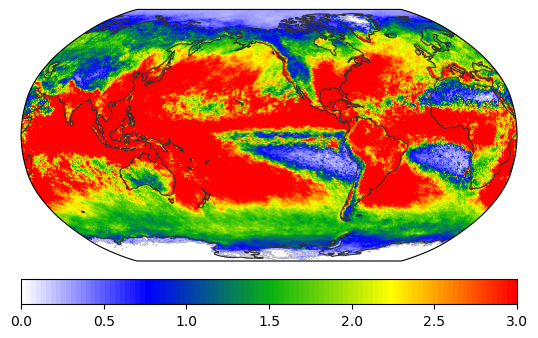

In [9]:
im = egh.healpix_show(ds.pr_p95.sel(source='obs1'), vmin=0, vmax=3, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05)

In [ ]:
im = egh.healpix_show(ds.pr_p95.sel(source='obs2'), vmin=0, vmax=3, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05)

<Figure size 640x480 with 0 Axes>

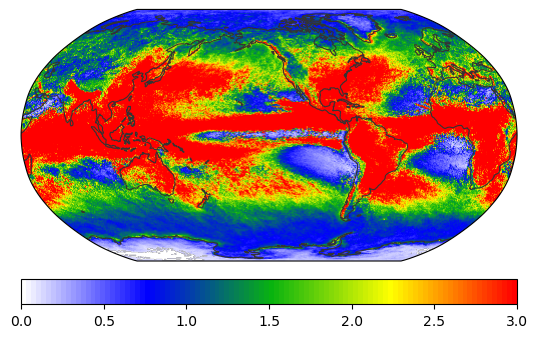

In [10]:
im = egh.healpix_show(ds.pr_p95.sel(source='m1'), vmin=0, vmax=3, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05)

## Function to plot contribution fraction maps

In [11]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """
    Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [ ]:
def plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                  min_thresh=None, wspace=None, hspace=None, oob_colors=None,
                  contourf=False, figsize=None, fontsize=None, cb_fontsize=None,
                  show_gridlines=False, figtitle=None, dpi=200, lat_lines=None,
                  zonal_lines=None, zonal_xlabel='Latitude (°)', zonal_ylabel=None, zonal_title=None,
                  zonal_legend_loc='best', zonal_height_ratio=0.85, zonal_width_frac=1.0, zonal_height_frac=1.0):
    """
    Plot a grid of maps with flexible dimensions

    Parameters:
    -----------
    da_list : list of lists
        2D list of xarray DataArrays to plot, dimensions should be [nrow][ncol]
    titles : list of lists
        2D list of titles for each panel, dimensions should be [nrow][ncol]
    levels, colormaps, etc.: can be single values applied to all panels or lists of lists matching da_list
    wspace, hspace : float or None
        Column/row spacing passed straight through to GridSpecFromSubplotSpec, exactly as given -- including whenever a
        zonal panel is present. (Earlier versions silently floored these to 0.12 whenever a zonal panel needed extra
        clearance; that made them impossible to tune below 0.12. Use zonal_width_frac/zonal_height_frac below for
        additional clearance beyond what wspace/hspace alone can give the zonal panel.)
    lat_lines : list or None
        List of latitude values to plot as horizontal lines (e.g., [-20, 20] for tropics)
    zonal_lines : list of dict, or None
        One extra, non-map panel: a zonal-mean line plot, styled like plot_zonal_mean_grid in
        plot_cof_total_rain_seasonal_zonalmean_maps.ipynb (2 degree latitude bins, unweighted mean -- valid since HEALPix
        cells are equal-area -- obs lines thicker than model lines). Each entry is a dict with 'label', 'lat' (1D latitude bin
        centers), 'mean' (1D values), 'color', 'linewidth', and optionally 'q25'/'q75' (1D values): when both are given, a
        shaded band is drawn under the line (the interquartile range of the zonal-mean line's own year-to-year values, not a
        zonal average of a cell-wise interannual spread -- computed by the caller). Placement: if da_list already has an
        empty (None) panel -- an odd number of sources in the grid -- the zonal panel is drawn there; otherwise a new row,
        spanning every column, is appended below the maps.
    zonal_xlabel, zonal_ylabel, zonal_title, zonal_legend_loc : the zonal panel's axis labels, panel title and legend
        location (default 'best': matplotlib places it wherever it best avoids the plotted lines).
    zonal_height_ratio : float
        Height of the appended zonal row relative to one map row (only used when a row is appended, not when an existing
        empty panel is reused). Default 0.85.
    zonal_width_frac, zonal_height_frac : float
        Fraction (0-1] of the zonal panel's own allocated grid width/height its axes actually occupies. width_frac shrinks
        from the LEFT (right edge fixed) -- clearance for the y-axis label/ticks from the panel to its left; height_frac
        shrinks from the TOP (bottom edge fixed, where the x-axis lives) -- clearance above the panel, e.g. from the title
        or the row above it. Both default to 1.0 (no shrink) -- independent, additional levers on top of wspace/hspace,
        for whatever clearance those alone don't give.
    """
    # Get grid dimensions from input data
    nrow = len(da_list)
    ncol = len(da_list[0]) if nrow > 0 else 0

    # Handle case where parameters might be the same for all panels
    def ensure_grid_format(param, param_name):
        if not isinstance(param, list):
            # If single value provided, apply to all panels
            return [[param for _ in range(ncol)] for _ in range(nrow)]
        elif isinstance(param, list):
            if len(param) == 0:
                # Empty list
                return [[[] for _ in range(ncol)] for _ in range(nrow)]
            elif isinstance(param[0], list):
                # Already a list of lists, return as is
                return param
            else:
                # It's a 1D list (like levels=[1,2,3,5,7,10]), use same list for all panels
                return [[param for _ in range(ncol)] for _ in range(nrow)]
        return param

    # Ensure all parameters have proper grid format
    colormaps = ensure_grid_format(colormaps, "colormaps")
    levels = ensure_grid_format(levels, "levels")
    cbticks = ensure_grid_format(cbticks, "cbticks")

    # Where the zonal panel goes: an existing empty (None) map slot (odd number of sources), else a new row spanning every
    # column (even number of sources, the grid is already full)
    zonal_slot = None
    if zonal_lines is not None:
        for r in range(nrow):
            for c in range(ncol):
                if da_list[r][c] is None:
                    zonal_slot = (r, c)
                    break
            if zonal_slot is not None:
                break
    add_zonal_row = zonal_lines is not None and zonal_slot is None

    mpl.rcParams['font.size'] = fontsize
    map_extent = [0, 360, -60, 60]
    proj = ccrs.Robinson(central_longitude=225)
    data_proj = ccrs.PlateCarree()
    resolution = '110m'
    land = cf.NaturalEarthFeature('physical', 'land', resolution)
    ocean = cf.NaturalEarthFeature('physical', 'ocean', resolution)
    borders = cf.NaturalEarthFeature('cultural', 'admin_0_boundary_lines_land', resolution)

    if add_zonal_row and figsize is not None:
        # Scale the figure height up proportionally so the appended row gets its own share of the canvas
        fig_w, fig_h = figsize
        figsize = (fig_w, fig_h * (nrow + zonal_height_ratio) / nrow)

    fig = plt.figure(figsize=figsize, dpi=100)
    # Setup two columns (left: plots, right: colorbar)
    gs0 = gridspec.GridSpec(1, 2, figure=fig, height_ratios=[1], width_ratios=[1,0.02], wspace=0.05)
    # Setup panels to the left: one extra row when a zonal panel is appended (not when it reuses an empty map slot)
    n_grid_rows = nrow + (1 if add_zonal_row else 0)
    h_ratios = list(np.repeat(1, nrow)) + ([zonal_height_ratio] if add_zonal_row else [])
    w_ratios = list(np.repeat(1, ncol))
    gs = gridspec.GridSpecFromSubplotSpec(n_grid_rows, ncol, subplot_spec=gs0[0],
                                         height_ratios=h_ratios, width_ratios=w_ratios,
                                         wspace=wspace, hspace=hspace)

    def draw_zonal_panel(ax):
        if zonal_width_frac < 1.0 or zonal_height_frac < 1.0:
            pos = ax.get_position()
            new_width = pos.width * zonal_width_frac
            new_height = pos.height * zonal_height_frac
            # width: shrink from the left (right edge fixed) -- clearance for the y-axis label from the panel to its left
            # height: shrink from the top (bottom edge fixed, where the x-axis lives) -- clearance above the panel
            ax.set_position([pos.x0 + (pos.width - new_width), pos.y0, new_width, new_height])
        for zl in zonal_lines:
            color = zl.get('color', 'gray')
            lw = zl.get('linewidth', 1.5)
            lat, mean = zl['lat'], zl['mean']
            ax.plot(lat, mean, color=color, linewidth=lw, label=zl['label'])
            if zl.get('q25') is not None and zl.get('q75') is not None:
                ax.fill_between(lat, zl['q25'], zl['q75'], color=color, alpha=0.2, linewidth=0)
        if zonal_title:
            ax.set_title(zonal_title, fontsize=fontsize, fontweight='bold', loc='left')
        ax.set_xlabel(zonal_xlabel, fontsize=fontsize)
        if zonal_ylabel:
            ax.set_ylabel(zonal_ylabel, fontsize=fontsize)
        ax.tick_params(axis='both', labelsize=max(fontsize * 0.8, 8))
        ax.grid(True, alpha=0.7, linestyle=':')
        ax.legend(loc=zonal_legend_loc, framealpha=0.9, fontsize=max(fontsize * 0.6, 8))

    # Loop over each panel in the grid
    cf1 = None  # Will store the last plot for colorbar
    for row in range(nrow):
        for col in range(ncol):
            # Get panel index
            panel_idx = row * ncol + col

            # Get data for this panel
            Var = da_list[row][col]
            if Var is not None:

                # Create subplot
                ax = plt.subplot(gs[panel_idx], projection=proj)
                ax.set_global()
                ax.add_feature(land, facecolor='none', edgecolor='k', zorder=3)
                ax.set_aspect('auto', adjustable=None)

                # Add title
                flabel = ax.text(0.02, 0.94, titles[row][col], transform=ax.transAxes, fontsize=fontsize)
                flabel.set_bbox(dict(facecolor='w', alpha=0.8, edgecolor='w'))

                # Apply minimum threshold if provided
                if min_thresh is not None:
                    Var = Var.where(Var > min_thresh)

                # Setup colormap
                cmap = copy.copy(mpl.colormaps.get_cmap(colormaps[row][col]))

                # Set out-of-bounds colors
                if oob_colors is not None:
                    oob_c = oob_colors
                    if oob_c is not None:
                        cmap.set_over(oob_c['over'])
                        cmap.set_under(oob_c['under'])

                # Create color normalization
                norm = colors.BoundaryNorm(boundaries=levels[row][col], ncolors=cmap.N)

                # Plot data
                if not contourf:
                    cf1 = egh.healpix_show(Var, ax=ax, cmap=cmap, norm=norm, zorder=2)
                else:
                    cf1 = egh.healpix_contour(Var, ax=ax, norm=norm, cmap=cmap, transform=data_proj, zorder=2)

                # Add gridlines
                if show_gridlines:
                    gl = ax.gridlines(crs=data_proj, draw_labels=False, linestyle='--', linewidth=0.5, zorder=10)

                # Add latitude lines if specified
                if lat_lines is not None:
                    for lat in lat_lines:
                        # Create longitude array spanning the globe
                        lons = np.linspace(-180, 180, 361)
                        lats = np.full_like(lons, lat)
                        ax.plot(lons, lats, color='k', linestyle='--', linewidth=1.5,
                            transform=data_proj, zorder=4, alpha=0.8)
            elif zonal_slot == (row, col):
                ax_zonal = plt.subplot(gs[panel_idx])
                draw_zonal_panel(ax_zonal)

    if add_zonal_row:
        ax_zonal = fig.add_subplot(gs[nrow, :])
        draw_zonal_panel(ax_zonal)

    # Add colorbar (using the last plotted data)
    if cf1 is not None:
        cax = plt.subplot(gs0[1])
        cbar = plt.colorbar(cf1, cax=cax, label=cblabels, ticks=cbticks[row][col],
                           orientation='vertical', extend='both')

    # Add suptitle
    if figtitle:
        fig.suptitle(figtitle, y=0.92, fontweight='bold')

    # Save figure
    fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
    return fig

In [ ]:
def compute_zonal_mean(da, lat_bins):
    """
    Zonal mean of a HEALPix DataArray (dim 'cell', with a 'lat' coordinate on it): the unweighted mean over the cells in
    each latitude bin, valid because HEALPix cells are equal-area by construction. Preserves any other dimension da has
    (e.g. 'year'). Adapted from compute_seasonal_zonal_mean in plot_cof_total_rain_seasonal_zonalmean_maps.ipynb, without
    its 'season' dimension.

    Parameters:
    -----------
    da : xarray.DataArray
        Values on the 'cell' dimension, with a 'lat' coordinate on that dimension.
    lat_bins : array-like
        Latitude bin edges.

    Returns:
    --------
    xarray.DataArray with 'cell' replaced by 'latitude' (bin centers).
    """
    lat_bins = np.asarray(lat_bins)
    lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
    result = da.groupby_bins('lat', bins=lat_bins).mean(dim='cell')
    result = result.rename({'lat_bins': 'latitude'}).assign_coords(latitude=lat_centers)
    return result


# 2-degree latitude bins over the full globe (the extreme-precipitation thresholds are not restricted to |lat| <= 60 the
# way the COF/MCS products are), matching the bin width of plot_cof_total_rain_seasonal_zonalmean_maps.ipynb
lat_bins = np.arange(-90, 91, 2)

# obs1/obs2 thicker and darker than the model lines, so they read as the reference pair (as in the seasonal notebook's
# color_dict, extended for the second observational product)
source_colors = {
    'obs1': 'black',
    'obs2': 'dimgray',
    'm1': 'dodgerblue',
    'm2': 'deeppink',
    'm3': 'green',
    'm4': 'lime',
    'm5': 'darkorange',
}
source_linewidths = {k: 3.0 if k in ('obs1', 'obs2') else 1.5 for k in source_colors}

In [ ]:
tropics_lat = [-20, 20]
extreme_percentile = 'p95'
VAR = f'pr_{extreme_percentile}'
annual_var = f'pr_annual_{extreme_percentile}'

# Create 2D lists for data and titles (7 sources: obs1, obs2, m1-m5; one empty panel, reused below for the zonal-mean panel)
da_list = [
    [ds[VAR].sel(source='obs1'), ds[VAR].sel(source='obs2')],
    [ds[VAR].sel(source='m1'), ds[VAR].sel(source='m2')],
    [ds[VAR].sel(source='m3'), ds[VAR].sel(source='m4')],
    [ds[VAR].sel(source='m5'), None],
]
titles = [
    [f"(a) {name_map_plot['obs1']}", f"(b) {name_map_plot['obs2']}"],
    [f"(c) {name_map_plot['m1']}", f"(d) {name_map_plot['m2']}"],
    [f"(e) {name_map_plot['m3']}", f"(f) {name_map_plot['m4']}"],
    [f"(g) {name_map_plot['m5']}", ""]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 16
cb_fontsize = 10
wspace = 0.1
hspace = 0.05
varname1 = '6-h Rain Rate'
units = 'mm/h'
figtitle = f'{extreme_percentile.upper()} Extreme Rain Rate'
lat_lines = tropics_lat

# Setup levels and colormap
levels = [0.1,0.2,0.4,0.6,1,1.5,2,2.5,3,4,6,8]
min_thresh = None
colormaps = cmaps.WhBlGrYeRe
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_extreme_precip_threshold_{extreme_percentile.upper()}.png'

# Zonal-mean panel: every source's zonal mean of pr_{extreme_percentile}; obs1/obs2 also get a shaded band -- the
# interquartile range, across years, of the zonally-averaged annual value itself (not a zonal average of the cell-wise
# pr_q25/pr_q75, which would understate the spread of the line since spatial averaging within a band already damps
# per-cell noise before any quantile is taken)
zonal_lines = []
for key in name_map.keys():
    zmean = compute_zonal_mean(ds[VAR].sel(source=key), lat_bins)
    entry = {'label': name_map_plot[key], 'lat': zmean['latitude'].values, 'mean': zmean.values,
             'color': source_colors[key], 'linewidth': source_linewidths[key]}
    if shade_interannual_iqr and years_dict[key] is not None and annual_var in ds.data_vars:
        zonal_annual = compute_zonal_mean(ds[annual_var].sel(source=key), lat_bins)  # (year, latitude)
        entry['q25'] = zonal_annual.quantile(0.25, dim='year').values
        entry['q75'] = zonal_annual.quantile(0.75, dim='year').values
    zonal_lines.append(entry)

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200,
                    zonal_lines=zonal_lines, zonal_title='(h) Zonal mean',
                    zonal_ylabel=f'{varname1} ({units})', zonal_legend_loc='best', zonal_width_frac=0.9)

In [ ]:
tropics_lat = [-20, 20]
extreme_percentile = 'p90'
VAR = f'pr_{extreme_percentile}'
annual_var = f'pr_annual_{extreme_percentile}'

# Create 2D lists for data and titles (7 sources: obs1, obs2, m1-m5; one empty panel, reused below for the zonal-mean panel)
da_list = [
    [ds[VAR].sel(source='obs1'), ds[VAR].sel(source='obs2')],
    [ds[VAR].sel(source='m1'), ds[VAR].sel(source='m2')],
    [ds[VAR].sel(source='m3'), ds[VAR].sel(source='m4')],
    [ds[VAR].sel(source='m5'), None],
]
titles = [
    [f"(a) {name_map_plot['obs1']}", f"(b) {name_map_plot['obs2']}"],
    [f"(c) {name_map_plot['m1']}", f"(d) {name_map_plot['m2']}"],
    [f"(e) {name_map_plot['m3']}", f"(f) {name_map_plot['m4']}"],
    [f"(g) {name_map_plot['m5']}", ""]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 16
cb_fontsize = 10
wspace = 0.1
hspace = 0.05
varname1 = '6-h Rain Rate'
units = 'mm/h'
figtitle = f'{extreme_percentile.upper()} Extreme Rain Rate'
lat_lines = tropics_lat

# Setup levels and colormap
levels = [0.1,0.2,0.4,0.6,1,1.5,2,2.5,3,4,6,8]
min_thresh = None
colormaps = cmaps.WhBlGrYeRe
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_extreme_precip_threshold_{extreme_percentile.upper()}.png'

# Zonal-mean panel: every source's zonal mean of pr_{extreme_percentile}; obs1/obs2 also get a shaded band -- the
# interquartile range, across years, of the zonally-averaged annual value itself (not a zonal average of the cell-wise
# pr_q25/pr_q75, which would understate the spread of the line since spatial averaging within a band already damps
# per-cell noise before any quantile is taken)
zonal_lines = []
for key in name_map.keys():
    zmean = compute_zonal_mean(ds[VAR].sel(source=key), lat_bins)
    entry = {'label': name_map_plot[key], 'lat': zmean['latitude'].values, 'mean': zmean.values,
             'color': source_colors[key], 'linewidth': source_linewidths[key]}
    if shade_interannual_iqr and years_dict[key] is not None and annual_var in ds.data_vars:
        zonal_annual = compute_zonal_mean(ds[annual_var].sel(source=key), lat_bins)  # (year, latitude)
        entry['q25'] = zonal_annual.quantile(0.25, dim='year').values
        entry['q75'] = zonal_annual.quantile(0.75, dim='year').values
    zonal_lines.append(entry)

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200,
                    zonal_lines=zonal_lines, zonal_title='(h) Zonal mean',
                    zonal_ylabel=f'{varname1} ({units})', zonal_legend_loc='best', zonal_width_frac=0.9)